<a href="https://colab.research.google.com/github/zrarey/ZechiusPrime/blob/main/ZRarey_Final_Music_Recommendation_System_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Music Recommendation System**

## **Problem Definition**

### **The Context:**
With the advent of technology, societies have become more efficient with their lives. At the same time, however, individual human lives have also become more fast-paced and distracted, leaving little time to pursue artistic activities. In addition, technology has made significant advancements in the ability to coexist with art and general entertainment. It has, in fact, made it easier for humans with a shortage of time to find and consume good content.
Almost every internet-based company's revenue relies on the amount of time that consumers spend on their platforms. These companies need to be able to figure out what kind of content is needed in order to increase customer time spent and make the user experience better. Therefore, one of the key challenges for these companies is figuring out what kind of content their customers are are most likely to consume.

Spotify is one such audio content provider with a huge market base across the world. with the ever-increasing volume of songs becoming available on the Internet, searching for songs of interest has become a tedious task in itself. However, Spotify has grown significantly in the market because of its ability to to recommend the 'best' next song to each and every customer based on a huge preference database gathered over time- millions of customers and billions of songs. This is done by using smart recommendation systems that can recommend songs based on users' likes/dislikes.  

### **The objective:**

 Build a recommendation system to propose the top songs for a user based on the likelihood of listening to those songs.
### **The key questions:**


* What is the proper metric for success?
*   How will the system deal with cold start issues?


*   What type of filtering system will work most efficiently for this problem? (Content-based filitering, Collaborative filtering, Hybrid, etc.)







### **The problem formulation**:

- What is it that we are trying to solve using data science?
* The problem we are trying to solve is to build a recommendation system that will propose the top 10 songs for the user based on the likelihood that they will listen to it. To accomplish this, we will perform EDA and cleaning on the data, modeling several algorithms for comparison, and selecting the most robust model based on evaluation metrics.

## **Data Dictionary**

The core data is the Taste Profile Subset released by the Echo Nest as part of the Million Song Dataset. There are two files in this dataset. The first file contains the details about the song id, titles, release, artist name, and the year of release. The second file contains the user id, song id, and the play count of users.

**song_data**

- song_id - A unique id given to every song
- title - Title of the song
- Release - Name of the released album
- Artist_name - Name of the artist
- year - Year of release

**count_data**

- user _id - A unique id given to the user
- song_id - A unique id given to the song
- play_count - Number of times the song was played

## **Data Source**
http://millionsongdataset.com/

### **Importing Libraries and the Dataset**

**Note**: After running this commands, you’ll be prompted to restart your notebook/runtime. Please go ahead and do that. Once restarted, simply proceed to the next step of your workflow

In [ ]:
!pip install numpy==1.26.0

In [ ]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Used to ignore the warning given as output of the code
import warnings
warnings.filterwarnings("ignore")

# Basic libraries of python for numeric and dataframe computations
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Import Matplotlib the Basic library for data visualization
import matplotlib.pyplot as plt


# Import the required library to compute the cosine similarity between two vectors
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

# Import mean_squared_error : a performance metrics in sklearn
from sklearn.metrics import mean_squared_error


### **Load the dataset**

In [ ]:
# Importing the datasets
song_data = pd.read_csv('/content/drive/MyDrive/song_data.csv')
count_data = pd.read_csv('/content/drive/MyDrive/count_data.csv')

### **Understanding the data by viewing a few observations**

In [ ]:
# Display first 10 records of count_df data
count_data.head(10)

,Unnamed: 0,user_id,song_id,play_count
0,0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
2,2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1
3,3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1
4,4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1
5,5,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODDNQT12A6D4F5F7E,5
6,6,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODXRTY12AB0180F3B,1
7,7,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOFGUAY12AB017B0A8,1
8,8,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOFRQTD12A81C233C0,1
9,9,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOHQWYZ12A6D4FA701,1


In [ ]:
# Display first 10 records of song_df data
song_data.head(10)

,song_id,title,release,artist_name,year
0,SOQMMHC12AB0180CB8,Silent Night,Monster Ballads X-Mas,Faster Pussy cat,2003
1,SOVFVAK12A8C1350D9,Tanssi vaan,Karkuteillä,Karkkiautomaatti,1995
2,SOGTUKN12AB017F4F1,No One Could Ever,Butter,Hudson Mohawke,2006
3,SOBNYVR12A8C13558C,Si Vos Querés,De Culo,Yerba Brava,2003
4,SOHSBXH12A8C13B0DF,Tangle Of Aspens,Rene Ablaze Presents Winter Sessions,Der Mystic,0
5,SOZVAPQ12A8C13B63C,"Symphony No. 1 G minor ""Sinfonie Serieuse""/All...",Berwald: Symphonies Nos. 1/2/3/4,David Montgomery,0
6,SOQVRHI12A6D4FB2D7,We Have Got Love,Strictly The Best Vol. 34,Sasha / Turbulence,0
7,SOEYRFT12AB018936C,2 Da Beat Ch'yall,Da Bomb,Kris Kross,1993
8,SOPMIYT12A6D4F851E,Goodbye,Danny Boy,Joseph Locke,0
9,SOJCFMH12A8C13B0C2,Mama_ mama can't you see ?,March to cadence with the US marines,The Sun Harbor's Chorus-Documentary Recordings,0


### **Let us check the data types and and missing values of each column**

In [ ]:
# Display info of count_df
count_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 4 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Unnamed: 0  int64 
 1   user_id     object
 2   song_id     object
 3   play_count  int64 
dtypes: int64(2), object(2)
memory usage: 61.0+ MB


In [ ]:
# Display info of song_df
song_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   song_id      1000000 non-null  object
 1   title        999983 non-null   object
 2   release      999993 non-null   object
 3   artist_name  1000000 non-null  object
 4   year         1000000 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 38.1+ MB


#### **Observations and Insights:** The first data set is count_data and it contains three columns: user_id, song_id, and play_count. The second data set is song_data and contains 5 columns: song_id, title, release, artist_name, and year. The two data sets contain only two types of data; objects and integers. The set song_data has some null values that will need to be addressed.


In [ ]:
#*****This cell was added after some inital EDA showed that some of the release years for songs were listed in the data set as "0". This code imputes the median value for all the songs with a release year designation of "0"
# To replace the zero value with a (NaN) designation
song_data['year'] = song_data['year'].replace(0, np.nan)
# To impute the data with the median of the years' range
song_data['year'] = song_data['year'].fillna(song_data['year'].median())
# In case any other song titles have a zero value for the year
song_data['year'] = song_data['year'].astype(int)

# Verification
print("Missing year remaining:", song_data['year'].isnull().sum())
print("Songs with year '0' remaining:", (song_data['year'] ==0).sum())

Missing year remaining: 0
Songs with year '0' remaining: 0


In [ ]:
# Left merge count_df and song_df on "song_id". Drop duplicates from song_df data simultaneously
df= pd.merge(count_data, song_data, on='song_id', how='left').drop_duplicates()
# Drop the column 'Unnamed: 0'
df= df.drop('Unnamed: 0', axis=1)
## Name the obtained dataframe as "df"

**Think About It:** As the user_id and song_id are encrypted. Can they be encoded to numeric features?

In [ ]:
# Apply label encoding for "user_id" and "song_id"
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to 'user_id' and 'song_id'
df['user_id_encoded'] = le.fit_transform(df['user_id'])
df['song_id_encoded'] = le.fit_transform(df['song_id'])

# Display the first few rows with the new encoded columns
print(df[['user_id', 'user_id_encoded', 'song_id', 'song_id_encoded']].head())

                                    user_id  user_id_encoded  \
0  b80344d063b5ccb3212f76538f3d9e43d87dca9e            54961   
1  b80344d063b5ccb3212f76538f3d9e43d87dca9e            54961   
2  b80344d063b5ccb3212f76538f3d9e43d87dca9e            54961   
4  b80344d063b5ccb3212f76538f3d9e43d87dca9e            54961   
5  b80344d063b5ccb3212f76538f3d9e43d87dca9e            54961   

              song_id  song_id_encoded  
0  SOAKIMP12A8C130995              153  
1  SOBBMDR12A8C13253B              413  
2  SOBXHDL12A81C204C0              736  
4  SOBYHAJ12A6701BF1D              750  
5  SODACBL12A8C13C273             1188  


**Think About It:** As the data also contains users who have listened to very few songs and vice versa, is it required to filter the data so that it contains users who have listened to a good count of songs and vice versa?

It is required to filter the data for a collaborative filtering system, as this system is not equipped to handle cold starts and is most effective with sufficient past interactions with users.

In [ ]:
# Get the column containing the users
users = df.user_id

# Create a dictionary that maps users(listeners) to the number of songs that they have listened to
playing_count = dict()

for user in users:
    # If we already have the user, just add 1 to their playing count
    if user in playing_count:
        playing_count[user] += 1

    # Otherwise, set their playing count to 1
    else:
        playing_count[user] = 1

In [ ]:
# We want our users to have listened at least 90 songs
SONG_COUNT_CUTOFF = 90

# Create a list of users who need to be removed
remove_users = []

for user, num_songs in playing_count.items():

    if num_songs < SONG_COUNT_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [ ]:
# Get the column containing the songs
songs = df.song_id

# Create a dictionary that maps songs to its number of users(listeners)
playing_count = dict()

for song in songs:
    # If we already have the song, just add 1 to their playing count
    if song in playing_count:
        playing_count[song] += 1

    # Otherwise, set their playing count to 1
    else:
        playing_count[song] = 1

In [ ]:
# We want our song to be listened by atleast 120 users to be considred
LISTENER_COUNT_CUTOFF = 120

remove_songs = []

for song, num_users in playing_count.items():
    if num_users < LISTENER_COUNT_CUTOFF:
        remove_songs.append(song)

df_final= df.loc[ ~ df.song_id.isin(remove_songs)]

Out of all the songs available, songs with play_count less than or equal to 5 are in almost 90% abundance. So for building the recommendation system let us consider only those songs.

In [ ]:
# Keep only records of songs with play_count less than or equal to (<=) 5
df_final = df_final[df_final.play_count<=5]

In [ ]:
# Check the shape of the data
print(df_final.shape)

(138301, 9)


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138301 entries, 209 to 2086699
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   user_id          138301 non-null  object
 1   song_id          138301 non-null  object
 2   play_count       138301 non-null  int64 
 3   title            138301 non-null  object
 4   release          138301 non-null  object
 5   artist_name      138301 non-null  object
 6   year             138301 non-null  int64 
 7   user_id_encoded  138301 non-null  int64 
 8   song_id_encoded  138301 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 10.6+ MB


In [ ]:
df_final.isnull().sum()

,0
user_id,0
song_id,0
play_count,0
title,0
release,0
artist_name,0
year,0
user_id_encoded,0
song_id_encoded,0


## **Exploratory Data Analysis**

### **Let's check the total number of unique users, songs, artists in the data**

Total number of unique user id

In [ ]:
# Display total number of unique user_id
df['user_id'].unique().shape[0]

3338

Total number of unique song id

In [ ]:
# Display total number of unique song_id
df['song_id'].unique().shape[0]

9999

Total number of unique artists

In [ ]:
# Display total number of unique artists
df['artist_name'].unique().shape[0]

3378

In [ ]:
df_final.describe( include = 'all'). T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,138301,3337,ce5c912bb8044f23fc0fc31bd986b8d0a7303db5,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
song_id,138301,620,SOWCKVR12A8C142411,1602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
play_count,138301.0,NaN,NaN,NaN,1.698614,1.088205,1.0,1.0,1.0,2.0,5.0
title,138301,629,Use Somebody,1602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release,138301,453,My Worlds,1967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_name,138301,247,Coldplay,6527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,138301.0,NaN,NaN,NaN,2003.445579,6.555471,1969.0,2002.0,2005.0,2008.0,2010.0
user_id_encoded,138301.0,NaN,NaN,NaN,38025.846581,22006.295037,11.0,19453.0,37168.0,56998.0,76347.0
song_id_encoded,138301.0,NaN,NaN,NaN,4907.965134,2904.916336,21.0,2234.0,4975.0,7562.0,9989.0


#### **Observations and Insights:**
After filtering the data for only users that have listened to a minimum of 90 songs and songs that have been played less than or equal to 5 times, the resulting dataframe has a total of 3,338 unique users, 9,999 unique songs, and 3,378 unique artists. This is a much more manageable amount of data to work with for the purposes of this recommendation system.


### **Let's find out about the most interacted songs and interacted users**

Most interacted songs

In [ ]:
# Calculate the total play count for each song
song_play_counts = df_final.groupby('song_id')['play_count'].sum().reset_index()
song_play_counts.rename(columns={'play_count': 'total_play_count'}, inplace=True)

# Sort by total_play_count in descending order and get the top 10
top_10_songs = song_play_counts.sort_values(by='total_play_count', ascending=False).head(10)

# Create a mapping from encoded song_id to title and artist_name from df_final
# This ensures we use the correct metadata corresponding to the encoded song_id
song_metadata = df_final[['song_id', 'title', 'artist_name']].drop_duplicates(subset=['song_id'])

# Merge top_10_songs with song_metadata to get song titles and artist names
# The 'song_id' column in top_10_songs is the encoded song_id, which matches 'song_id' in song_metadata
top_10_songs_details = pd.merge(top_10_songs, song_metadata, on='song_id', how='left')

# Display the top 10 songs by play count
display(top_10_songs_details[['title', 'artist_name', 'total_play_count']])

# Get the shape before dropping duplicates
initial_shape = df_final.shape
print(f"Initial shape of df_final: {initial_shape}")

# Drop duplicate rows
df_final.drop_duplicates(inplace=True)

# Get the shape after dropping duplicates
final_shape = df_final.shape
print(f"Final shape of df_final after dropping duplicates: {final_shape}")

print(f"Number of rows removed: {initial_shape[0] - final_shape[0]}")

,title,artist_name,total_play_count
0,Use Somebody,Kings Of Leon,3126
1,Yellow,Coldplay,2216
2,Somebody To Love,Justin Bieber,1774
3,Supermassive Black Hole (Twilight Soundtrack V...,Muse,1762
4,Dog Days Are Over (Radio Edit),Florence + The Machine,1752
5,Sehr kosmisch,Harmonia,1692
6,Love Story,Taylor Swift,1660
7,Nothin' On You [feat. Bruno Mars] (Album Version),B.o.B,1592
8,Seven Nation Army,The White Stripes,1580
9,Secrets,OneRepublic,1531


Initial shape of df_final: (138301, 9)
Final shape of df_final after dropping duplicates: (138301, 9)
Number of rows removed: 0


Most interacted users

In [ ]:
# Calculate the total play count for each user
user_play_counts = df_final.groupby('user_id')['play_count'].sum().reset_index()
user_play_counts.rename(columns={'play_count': 'total_play_count'}, inplace=True)

# Sort by total_play_count in descending order and get the top 10 users
top_10_users = user_play_counts.sort_values(by='total_play_count', ascending=False).head(10)

# Display the top 10 users by play count
print("Top 10 most interacted users:")
display(top_10_users)



Top 10 most interacted users:


,user_id,total_play_count
147,0b19fe0fad7ca85693846f7dad047c449784647e,631
693,34e191b5e3ac4d0b86b100e3325aa46c34998248,501
2751,d2ac268dd7f11d013c3ec96c6dc0937ba7fe731f,479
1879,90141787198af4e517162e40a6231a5f3cdb03ea,459
1193,5bdf9d84164a807c4fb4382435320880747a01a2,448
1638,7c80116b2a5c6602ca60fc40ef932e12fd304a69,442
2887,de9f59adc2abb31c8478a0239b07a39001d5be1f,436
2126,a34c6288d3953fe656ede1555b2d7277dc6a3086,436
1012,4e3398ef89d9c00975d0b0f5b7bc7b7f067c7902,434
864,425a1df769f1e9ab022df488d3d50561baeec7a4,428


#### **Observations and Insights:**
By calculating the total number of plays per song and merging the data sets, we are able to identify the top ten songs and their total play counts, as well as determining those users with the most frequent app interaction. Intitial data suggests that content based or collaborative filtering are potential models to solve this problem.


Songs released on yearly basis

In [ ]:
# Find out the number of songs released in a year, use the songs_df
  # Hint: Use groupby function on the 'year' column
df_final.groupby('year')['song_id'].count().reset_index()

,year,song_id
0,1969,244
1,1970,191
2,1971,139
3,1973,426
4,1974,617
5,1975,181
6,1976,504
7,1978,307
8,1979,376
9,1980,248


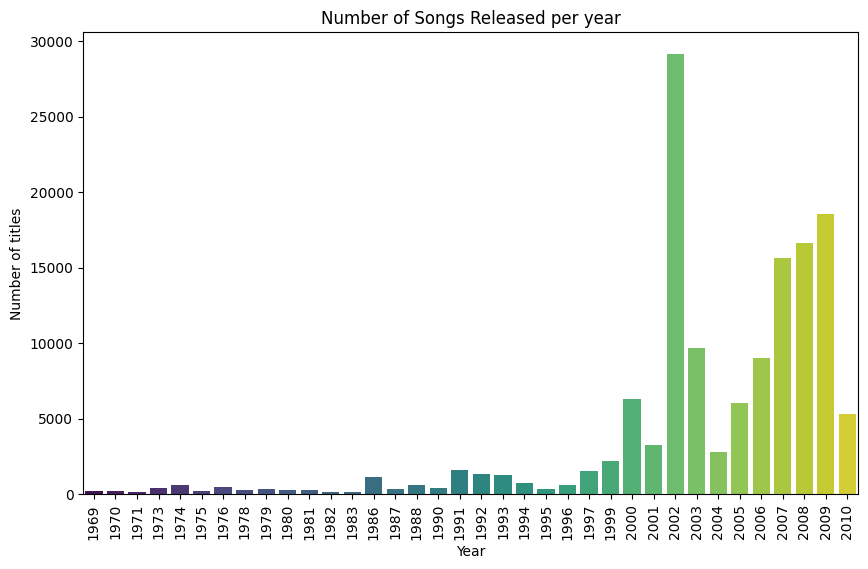

In [ ]:
# Create a barplot plot with y label as "number of titles played" and x -axis year

# Set the figure size
plt.figure(figsize=(10, 6))
# Create the bar plot
sns.barplot(x='year', y='song_id', data=df_final.groupby('year').count().reset_index(), palette = 'viridis')
# Set the x label of the plot
plt.xlabel('Year')
plt.xticks(rotation=90)
# Set the y label of the plot
plt.ylabel('Number of titles')
# Set title for the plot
plt.title('Number of Songs Released per year')
# Show the plot
plt.show()

In [ ]:
# Display songs where the song year is "0"
#songs_year_zero= df_final[df_final['year'] ==0]
#display(songs_year_zero)

In [ ]:
# songs_year_zero.shape


In [ ]:
# songs_year_zero.duplicated().sum()

In [ ]:
# Sanity Check that the amount of songs suggested by songs_year_zero is not actually 23,404
#missing_year_df = df_final[df_final['year'] == 0]
#print('Total Rows (interactions):', len(missing_year_df))
#print("Actual Unique songs:", missing_year_df['song_id'].nunique())



Initially, the graph showed that there are a varitey of artists whose songs' publication years were mislabeled as "0" in the data. We can handle these omissions in a number of ways, namely, deletion, imputation, or using external resources to fill out the correct data.
Since the actual number of songs that have missing data is not very large, the best options would probably be to either impute or delete. Models learn better with more information, so the impute option is the best option at this point. To do that, code will be added to remove the zero value and replace it with the median value. The necessary code will need to take place prior to the merge to ensure that all the titles with zero as the year are treated before processing the data. The prior steps I tried to solve this issue have been commented out.

In [ ]:
df_final.groupby('title')['play_count'].sum().reset_index().sort_values(by='play_count', ascending=False)

,title,play_count
573,Use Somebody,3126
615,Yellow,2216
461,Somebody To Love,1774
121,Dog Days Are Over (Radio Edit),1752
439,Sehr kosmisch,1692
...,...,...
152,Fake Tales Of San Francisco,121
153,Fake Tales Of San Francisco (Explicit),121
114,Did It Again,69
116,Did it Again,69


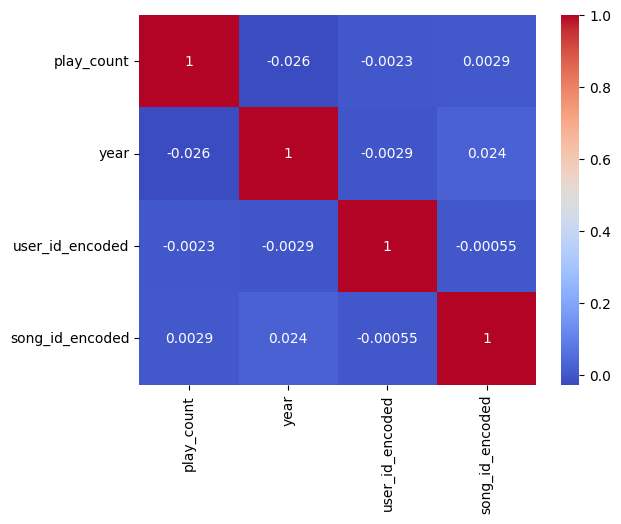

In [ ]:
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

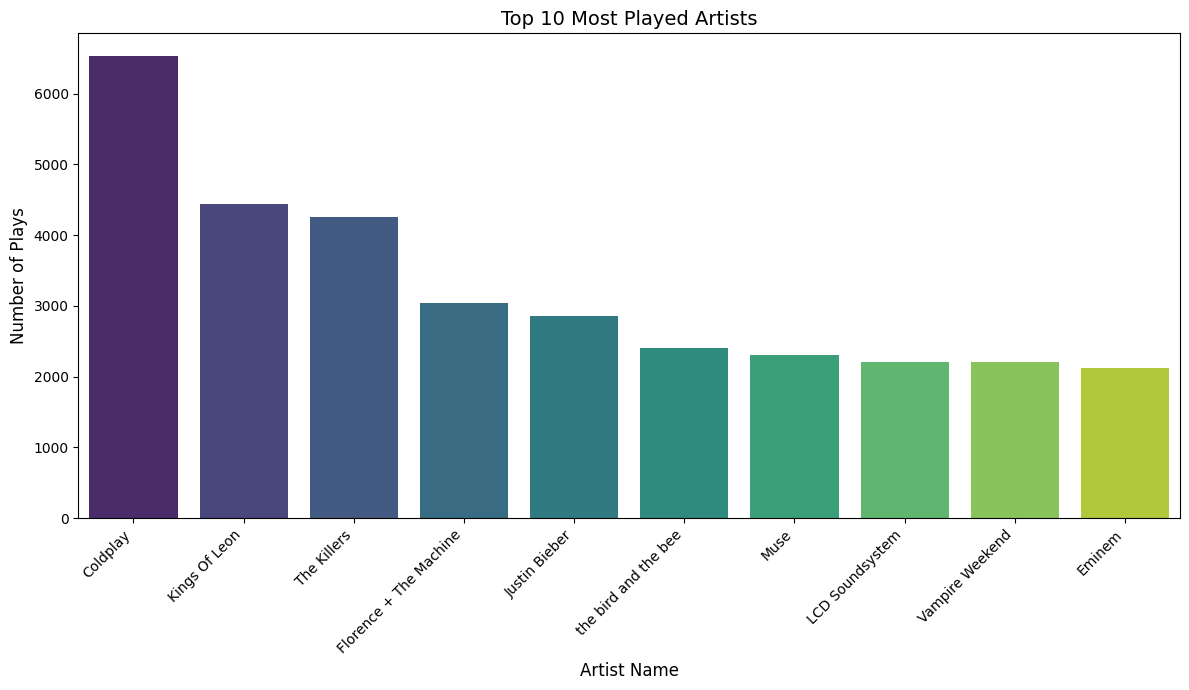

In [ ]:
# Get the top 10 most frequent artists
top_artists = df_final['artist_name'].value_counts().head(10)

# Create a bar plot for the top artists
plt.figure(figsize=(12, 7))
sns.barplot(x=top_artists.index, y=top_artists.values, palette='viridis')
plt.xlabel('Artist Name', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.ylabel('Number of Plays', fontsize=12)
plt.title('Top 10 Most Played Artists', fontsize=14)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
# Calculate the average release year for each artist
artist_avg_year = df_final.groupby('artist_name')['year'].mean().sort_values(ascending=False).reset_index()

# Display the top 10 artists by average release year
print("Top 10 Artists by Average Release Year (Newest first):")
display(artist_avg_year.head(10))

# Display the bottom 10 artists by average release year
print("\nBottom 10 Artists by Average Release Year (Oldest first):")
display(artist_avg_year.tail(10))

Top 10 Artists by Average Release Year (Newest first):


,artist_name,year
0,Frightened Rabbit,2010.000000
1,Usher featuring will.i.am,2010.000000
2,DJ Khaled,2010.000000
3,Two Door Cinema Club,2010.000000
4,Usher,2010.000000
5,Kid Cudi / MGMT / Ratatat,2010.000000
6,Aloe Blacc,2010.000000
7,Justin Bieber,2009.687194
8,A Day To Remember,2009.000000
9,La Roux,2009.000000



Bottom 10 Artists by Average Release Year (Oldest first):


,artist_name,year
237,Aerosmith,1979.523810
238,Tavares,1979.000000
239,The Buggles,1979.000000
240,Triumvirat,1978.000000
241,Eagles,1976.000000
242,Bill Withers,1975.000000
243,Cartola,1974.440310
244,Lynyrd Skynyrd,1974.000000
245,Cat Stevens,1970.000000
246,Creedence Clearwater Revival,1969.725849


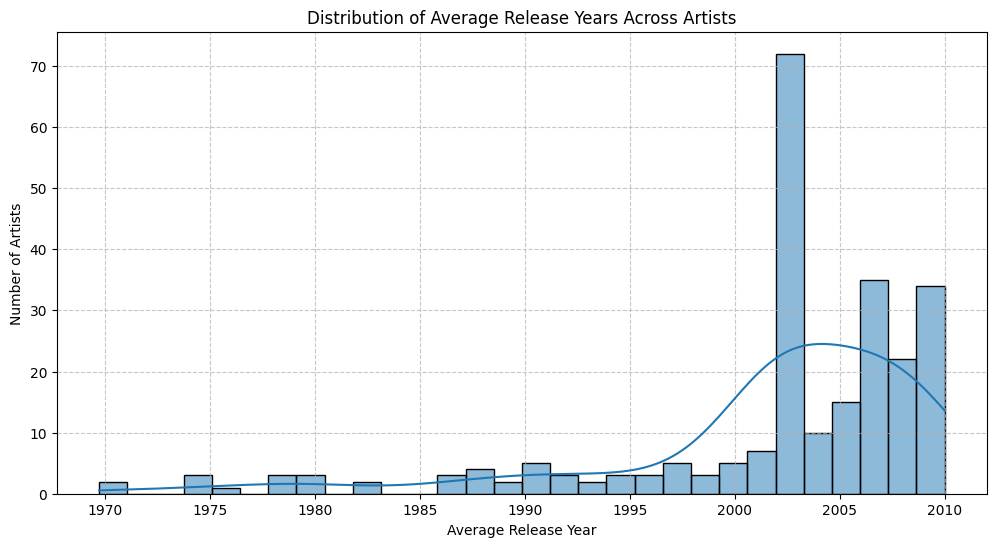

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's visualize the distribution of average release years for artists
plt.figure(figsize=(12, 6))
sns.histplot(artist_avg_year['year'], bins=30, kde=True)
plt.title('Distribution of Average Release Years Across Artists')
plt.xlabel('Average Release Year')
plt.ylabel('Number of Artists')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Let's look at the songs played most frequently
top_songs = df_final['title'].value_counts().head(10)
display(top_songs)


,count
title,
Use Somebody,1602
Yellow,1264
Don't Stop The Music,960
Somebody To Love,920
Love Story,910
Nothin' On You [feat. Bruno Mars] (Album Version),820
Dog Days Are Over (Radio Edit),802
Sehr kosmisch,767
Clocks,707


In [ ]:
# Let's look at the maximum number of songs played in a year per user
max_songs_per_user = df_final.groupby('user_id')['song_id'].count().max()
display(max_songs_per_user)

282

#### **Observations and Insights:** #
*    There was a significant increase in songs beginning in the early 2000s, peaking around 2007-2009. For example, 15,623 songs were released in 2007, 16,626 songs were released in 2008, and 18,554 songs were released in 2009, before steeply dropping off to around 5,000 songs in 2010.
*   Years before 1990 generally show very low numbers of song releases. We can see from the chart that the information contained in the data sets ranges from the year 1969 to the year 2010.

* The maximum amount of songs listened to by any user was 282.

* The highest play count of any song was 1,602 plays.

*   This graph also illustrates a problem in the data: there are many songs with inaccurate release year data.  We will need to treat those values before moving forward.


*  The data shows a strong right skew, which makes sense considering streaming services are relatively new, in addition to the idea that much of the music written prior to the modern era is likey not digitized for online streaming.




**Think About It:** What other insights can be drawn using exploratory data analysis?

In addition to above insights, we can also see that the numeric columns in the dataset have little to no correlation to one another, and that, even though Kings of Leon has the song with the most plays, Coldplay is the artist with the most overall plays. The last two charts were suggested and generated by Gemini, and although they are not necessarily important for this exercise, they do provide insights about the top and bottom artist for each year, as well as the distribution of the average amount of songs released each year.



Now that we have explored the data, let's apply different algorithms to build recommendation systems.

**Note:** Use the shorter version of the data, i.e., the data after the cutoffs as used in Milestone 1.

## Building various models

### **Popularity-Based Recommendation Systems**

Let's take the count and sum of play counts of the songs and build the popularity recommendation systems based on the sum of play counts.

In [ ]:
# Calculating average play_count
       # Hint: Use groupby function on the song_id column
average_play_count = df_final.groupby('song_id')['play_count'].mean().reset_index()
average_play_count.rename(columns={'play_count': 'average_count'}, inplace=True)
# Calculating the frequency a song is played
      # Hint: Use groupby function on the song_id column
song_play_freq = df_final.groupby('song_id')['play_count'].count().reset_index()
song_play_freq.rename(columns={'play_count': 'play_freq'}, inplace=True)

In [ ]:
# Making a dataframe with the average_count and play_freq
final_play = pd.merge(average_play_count, song_play_freq, on='song_id', how='inner')
# Let us see the first five records of the final_play dataset
print(final_play.head())

              song_id  average_count  play_freq
0  SOABJBU12A8C13F63F       1.631387        274
1  SOABJTC12A58A7DE0E       1.464286        140
2  SOADISH12AB018DFAC       1.616822        107
3  SOADJQJ12A8C141D38       1.715232        453
4  SOADQPP12A67020C82       1.727273        121


Now, let's create a function to find the top n songs for a recommendation based on the average play count of song. We can also add a threshold for a minimum number of playcounts for a song to be considered for recommendation.

In [ ]:
# Build the function to find top n songs
def top_n_songs_recommendations(data, n, min_play_freq= 50):
  # Filter out the songs with a play count lower than 50
  data= data[data['play_freq'] >= min_play_freq]
  # Sort by average play countin descending order
  top_songs_details= data.sort_values(by='average_count', ascending=False)
  # Merge with song data to get song details
  top_songs_details= pd.merge(top_songs_details, song_data[['song_id', 'title', 'artist_name']], on='song_id', how='left')
  return top_songs_details[['title', 'artist_name', 'average_count', 'play_freq']]

In [ ]:
# Recommend top 10 songs using the function defined above
top_10_popular_songs = top_n_songs_recommendations(final_play, 10)
print('Top 10 Popular Songs:')
display(top_10_popular_songs)

Top 10 Popular Songs:


,title,artist_name,average_count,play_freq
0,Victoria (LP Version),Old 97's,3.366972,109
1,Brave The Elements,Colossal,2.618182,110
2,The Big Gundown,The Prodigy,2.611650,103
3,Greece 2000,Three Drives,2.484277,159
4,Video Killed The Radio Star,The Buggles,2.307692,130
...,...,...,...,...
692,Him,Lily Allen,1.278846,208
693,Him,Lily Allen,1.278846,208
694,Pistol Of Fire,Kings Of Leon,1.254237,118
695,Pistol Of Fire,Kings Of Leon,1.254237,118


In [ ]:
top_10_popular_songs.head(10)

,title,artist_name,average_count,play_freq
0,Victoria (LP Version),Old 97's,3.366972,109
1,Brave The Elements,Colossal,2.618182,110
2,The Big Gundown,The Prodigy,2.611650,103
3,Greece 2000,Three Drives,2.484277,159
4,Video Killed The Radio Star,The Buggles,2.307692,130
5,Secrets,OneRepublic,2.305723,664
6,Luvstruck,Southside Spinners,2.283019,159
7,Transparency,White Denim,2.272727,110
8,You're The One,Dwight Yoakam,2.236908,401
9,Sehr kosmisch,Harmonia,2.205997,767


### **User User Similarity-Based Collaborative Filtering**

To build the user-user-similarity-based and subsequent models we will use the "surprise" library.

In [ ]:
# Install the surprise package using pip. Uncomment and run the below code to do the same

!pip install surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554994 sha256=cd0b2dcd46be0cc864925a8b7d07cfdbe4e17520b17d73044a99cd4bd3cc2cb2
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [ ]:
# Import necessary libraries

# To compute the accuracy of models
from surprise import accuracy

# This class is used to parse a file containing play_counts, data should be in structure - user; item; play_count
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the data in train and test dataset
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# For implementing KFold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise.prediction_algorithms.co_clustering import CoClustering



### Some useful functions

Below is the function to calculate precision@k and recall@k, RMSE, and F1_Score@k to evaluate the model performance.

**Think About It:** Which metric should be used for this problem to compare different models?

It is probably most pragmatic to avoid overreliance on only one metric to compare the models. Given that the objective is to recommend songs to users based on the likelihood that they will listen to them, the most important metrics will be the precision_@K scores, Recall@k, and F1_score@K. It is important to note, however,  that the RSME is still very important, since a model with low RSME scores is more likely to generate accurate "likelihood of listening" scores which will help generate better results in a rank based system.  

In [ ]:
def precision_recall_at_k(model, k=30, threshold=1.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user.
    user_est_true = defaultdict(list)

    #Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, playing_count in user_est_true.items():

        # Sort play count by estimated value
        playing_count.sort(key=lambda x: x[0], reverse=True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in playing_count)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in playing_count[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in playing_count[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. We here set Precision to 0 when n_rec_k is 0.

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. We here set Recall to 0 when n_rel is 0.

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    #Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)),3)
    #Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)),3)

    accuracy.rmse(predictions)
    print('Precision: ', precision) #Command to print the overall precision
    print('Recall: ', recall) #Command to print the overall recall
    print('F_1 score: ', round((2*precision*recall)/(precision+recall),3)) # Formula to compute the F-1 score.

**Think About It:** In the function precision_recall_at_k above the threshold value used is 1.5. How precision and recall are affected by changing the threshold? What is the intuition behind using the threshold value of 1.5?

The intuition behind using a higher threshold for the precision_recall_at_k value is to differentiate between casual and engaged listeners. A play count of 1 could indicate a casual listener or an unintended play. Setting the threshold higher than 1, we are telling the model that only the songs with a play count of 2 or higher should be considered relevant.  

Below we are loading the **dataset**, which is a **pandas dataframe**, into a **different format called `surprise.dataset.DatasetAutoFolds`** which is required by this library. To do this we will be **using the classes `Reader` and `Dataset`**

You will also notice here that we read the dataset by providing a scale of ratings. However, as you would know, we do not have ratings data of the songs. In this case, we are going to use play_count as a proxy for ratings with the assumption that the more the user listens to a song, the higher the chance that they like the song

In [ ]:
# Instantiating Reader scale with expected rating scale
 #use rating scale (0, 5)
reader= Reader(rating_scale=(0,5))
# Loading the dataset
 # Take only "user_id","song_id", and "play_count"
data= Dataset.load_from_df(df_final[['user_id', 'song_id', 'play_count']], reader)
# Splitting the data into train and test dataset
 # Take test_size = 0.4, random_state = 42
trainset, testset = train_test_split(data, test_size=0.4, random_state=42)

**Think About It:** How changing the test size would change the results and outputs?

Changing the test and train set size can impact the ability of the model to produce the most accurate results. If a test set is larger, then the training set will be smaller and the model should be able to more accurately detect robust patterns. The downside is that the model can overfit the data and may cause a higher variance, and has potential to lead to significantly different evaluation scores. Lastly, if the model is overfitting the data, it will likely have poor performance on unseen data. If the test set is smaller, then the training set will be larger and generally provide a more representative and reliable estimation of its performance. The downside of this situation is that,  as discussed with the intuition behind a higher threshold, there exists a Bias-Variance tradeoff. Smaller test sets can lead to high variance and unreliable evaluation scores. Larger test sets provide more stable models, but also risk introducing more bias that could lead to a less efficient model.

In [ ]:
# Build the default user-user-similarity model
sim_options = {'name': 'cosine','user_based': True}


# KNN algorithm is used to find desired similar items
 # Use random_state = 1
sim_user_user= KNNBasic(sim_options=sim_options, random_state=1)

# Train the algorithm on the trainset, and predict play_count for the testset
sim_user_user.fit(trainset)

# Make predictions on the testset
predictions = sim_user_user.test(testset)

# Then compute RMSE
rsme = accuracy.rmse(predictions)

# Let us compute precision@k, recall@k, and f_1 score with k = 30
 # Use sim_user_user model
precision_recall_at_k(sim_user_user, 30, 1.5)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0817
RMSE: 1.0817
Precision:  0.401
Recall:  0.705
F_1 score:  0.511


**Observations and Insights:**


*  RSME: A score of 1.0817 is a little higher than optimal but still very close to 1.

*   Precision: The precision score is not optimal at .401, so we will try to optimize with tuning.  
*   Recall: The model's recall is high, which could caused by the low precision score, so we will try to optimize this score with tuning as well.


*   F1: An F1 score of .511 is a mediocre score, indicating this model has significant room for improvement.



In [ ]:
# Predicting play_count for a sample user with a listened song
# Use any user id  and song_id
sim_user_user.predict(uid=6958, iid=1671, r_ui= 1, verbose=True)

user: 6958       item: 1671       r_ui = 1.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=1671, r_ui=1, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
# Predicting play_count for a sample user with a song not-listened by the user
 #predict play_count for any sample user
sim_user_user.predict(uid=6958, iid=3232, r_ui=1, verbose=True)

user: 6958       item: 3232       r_ui = 1.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=3232, r_ui=1, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations and Insights:**

When the model is throwing errors like "was impossible" and "Unknown item or user" it illustrates a limitation of the collaborative filtering method: the cold start problem. This model relies heavily on its training data and cannot provide accurate recommendations without sufficient past interaction. Possible solutions to this problem could be utilizing a popularity based filter that will recommend popular and trending songs to all users until users establish a minimum threshold of interaction, or creating a short onboarding process for new users  designed to collect user preferences that will be fed to the model to provide new recommendations.

Now, let's try to tune the model and see if we can improve the model performance.

In [ ]:
# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [20,30,40], 'min_k': [5,10], 'sim_options': {'name': ['cosine', 'pearson', 'msd'], 'user_based': [True]}}

# Performing 3-fold cross-validation to tune the hyperparameters
gs = GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting the data
 # Use entire data for GridSearch
gs.fit(data)
# Best RMSE score
print(f'Best RSME score: {gs.best_score["rmse"]}')
# Extract the combination of parameters that gave the best RMSE score
print(f'Best parameters: {gs.best_params["rmse"]}')


Best RSME score: 1.0163235261198789
Best parameters: {'k': 40, 'min_k': 10, 'sim_options': {'name': 'msd', 'user_based': True}}


In [ ]:
# Train the best model found in above gridsearch
sim_user_optimized= KNNBasic(k=40, min_k= 10, sim_options={'name': 'msd', 'user_based': True}, random_state=1)
sim_user_optimized.fit(trainset)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [ ]:
# Let's compute the precision@k, recall@K, and F_1 score with k = 30 for the optimized model
precision_recall_at_k(sim_user_optimized, 30, 1.5)

RMSE: 1.0234
Precision:  0.446
Recall:  0.635
F_1 score:  0.524


**Observations and Insights:**

*  RSME: our optimized score is still slighty high, but much closer to 1.

*   Precision: The precision score did not improve much rising to .446 from .401.
*   Recall: The model's recall is still high, but the score decreased moderately; likely due to the increase in the precision score.


*   F1: An F1 score of .524 is still a mediocre score, but given we have already computed the best parameters for this model, it is likely that we may unable to improve it further.




In [ ]:
# Predict the play count for a user who has listened to the song. Take user_id 6958, song_id 1671 and r_ui = 2
sim_user_user.predict(uid=6958, iid=1671, r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
# Predict the play count for a song that is not listened to by the user (with user_id 6958)
sim_user_user.predict(uid=6958, iid=3232, r_ui=1, verbose=True)

user: 6958       item: 3232       r_ui = 1.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=3232, r_ui=1, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations and Insights:**

User-User Similarity can recommend content to users based on what they may share in common with other users.
Precision improved from 0.401 to 0.446 after tuning. This means roughly 45%, or 13, of the top 30 recommendations were considered relevant. The recall score is moderate at 0.635, which means that it is relatively good at identifying most of the songs users might enjoy.


**Think About It:** Along with making predictions on listened and unknown songs can we get 5 nearest neighbors (most similar) to a certain song?

Below we will be implementing a function where the input parameters are:

- data: A **song** dataset
- user_id: A user-id **against which we want the recommendations**
- top_n: The **number of songs we want to recommend**
- algo: The algorithm we want to use **for predicting the play_count**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [ ]:
# Get the inner ID of the song for which we want neighbors (e.g., inner ID 0)
item_inner_id = 0

# Get the corresponding raw song_id (string) from the trainset
queried_song_id_str = trainset.to_raw_iid(item_inner_id)

# Get song details for the queried song from the song_data DataFrame
queried_song_details = song_data[song_data['song_id'] == queried_song_id_str].iloc[0]
queried_song_title = queried_song_details['title']
queried_song_artist = queried_song_details['artist_name']

# Get the 5 nearest neighbors (inner IDs) for the item_inner_id
song_neighbors_inner_ids = sim_user_optimized.get_neighbors(item_inner_id, k=5)

# Convert neighbor inner IDs to their raw song_id (strings)
neighbor_song_id_strs = [trainset.to_raw_iid(inner_id) for inner_id in song_neighbors_inner_ids]

# Get song details for these neighbors from song_data
neighbor_songs_details = song_data[song_data['song_id'].isin(neighbor_song_id_strs)]

print(f"The 5 nearest neighbors for song '{queried_song_title}' by '{queried_song_artist}' (ID: {queried_song_id_str}) are:")
display(neighbor_songs_details[['title', 'artist_name', 'song_id']])

The 5 nearest neighbors for song 'Fast As I Can' by 'Erin McKeown' (ID: SODUANR12A6D4F5036) are:


,title,artist_name,song_id
79923,Heartbreakin' Wreck,The Boxmasters,SOFQFWN12A58A7A84E
375517,Easy Love,MSTRKRFT,SOIYHAZ12A6D4F6D30
592341,We Will Become Silhouettes (Album),Postal Service,SOZHJKI12A81C2248F
795997,Our Song,Taylor Swift,SOUVGJL12AB017FC35
945202,Girlfriend,Phoenix,SOQFEDG12AB018DD24


In [ ]:
def get_recommendations(data_df, user_id, top_n, algo):
  # Creating an empty list to store the recommended song ids and their predicted play counts
  recommendations = []

  # Get songs already interacted by the specified user
  # user_id should be the raw user_id string (from df_final['user_id'])
  user_interacted_songs = data_df[data_df['user_id'] == user_id]['song_id'].unique()

  # Extracting those song ids which the user_id has not played yet
  all_song_ids = data_df['song_id'].unique()
  unplayed_songs = [song_id for song_id in all_song_ids if song_id not in user_interacted_songs]

  # Looping through each of the song ids which user_id has not interacted yet
  for song_id in unplayed_songs:
    # Predicting the play count for those non-played song ids by this user
    # algo.predict expects raw user_id and song_id strings
    predicted_play_count = algo.predict(user_id, song_id).est
    # Appending the predicted play_counts
    recommendations.append((song_id, predicted_play_count))

  # Sorting the predicted play_counts in descending order after the loop completes
  recommendations.sort(key = lambda x: x[1], reverse = True)

  # Returning top n highest predicted play_counts
  return recommendations[:top_n]

In [ ]:
# Make top 5 recommendations for any user_id with a similarity-based recommendation engine
# Use the optimized user-user similarity model for predictions
# For this example, we will just predict for one specific song
sim_user_optimized.predict(uid='6958', iid='1671', r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid='6958', iid='1671', r_ui=2, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
# Make top 5 recommendations for a sample user
# Get a valid raw user_id from df_final for the prediction
sample_raw_user_id = df_final['user_id'].iloc[0] # Using the first user from the filtered dataframe

print(f"Generating recommendations for user: {sample_raw_user_id}")

# Get raw recommendations (list of tuples: (song_id, predicted_play_count))
recommendations_list = get_recommendations(df_final, sample_raw_user_id, 5, sim_user_optimized)
print("Top 5 raw recommended songs for the user (song_id, predicted_play_count):")
display(recommendations_list)

# Convert the list of recommendations into a DataFrame
recommendations_df_for_merge = pd.DataFrame(recommendations_list, columns=['song_id', 'predicted_play_count'])

# Merge with song_data to get title and artist
final_recommendations = pd.merge(recommendations_df_for_merge, song_data[['song_id', 'title', 'artist_name']], on='song_id', how='left')
display(final_recommendations[["title", "artist_name", 'predicted_play_count']])

Generating recommendations for user: 17aa9f6dbdf753831da8f38c71b66b64373de613
Top 5 raw recommended songs for the user (song_id, predicted_play_count):


[('SOSJSSU12A6D4F8F41', 3.434130140879505),
 ('SONMIKP12A58A7E1FF', 2.701890989988877),
 ('SOJYBJZ12AB01801D0', 2.668535323814539),
 ('SOOGNOZ12AAF3B2936', 2.586124216876789),
 ('SOQGSUC12A8C13B66D', 2.5444230175443794)]

,title,artist_name,predicted_play_count
0,Victoria (LP Version),Old 97's,3.434130
1,No You Girls,Franz Ferdinand,2.701891
2,No You Girls,Franz Ferdinand,2.701891
3,No You Girls,Franz Ferdinand,2.701891
4,Shots,LMFAO / Lil Jon,2.668535
5,Transparency,White Denim,2.586124
6,Brave The Elements,Colossal,2.544423


**Observations and Insights:**
The model was able to identify and recommend the top 5 songs that are most like a given song using the K-nearest Neighbors algorithm.


### Correcting the play_counts and Ranking the above songs

In [ ]:
def ranking_songs(recommendations, song_data_df, final_play_df):
  # Convert list of tuples to DataFrame
  recommended_songs_df = pd.DataFrame(recommendations, columns=['song_id', 'predicted_play_count'])

  # The song_id in recommendations is already the raw song_id, so no mapping from 'song_id_encoded' is needed here.

  # Merge with song_data_df to get title and artist
  song_metadata_for_merge = song_data_df[['song_id', 'title', 'artist_name']].drop_duplicates(subset=['song_id'])
  recommended_songs_df = pd.merge(recommended_songs_df, song_metadata_for_merge, on='song_id', how='left')

  # Merge with final_play_df to get actual play frequency
  ranked_songs = pd.merge(recommended_songs_df, final_play_df[['song_id', 'play_freq']], on='song_id', how='left')

  # Correct the predicted play_counts.
  # Handle potential NaN values in 'play_freq' to avoid errors during calculation.
  ranked_songs['play_freq'] = ranked_songs['play_freq'].fillna(1) # Fill NaN with 1 to avoid division by zero/NaN issues
  ranked_songs['corrected_play_count'] = ranked_songs['predicted_play_count'] - (1 / np.sqrt(ranked_songs['play_freq']))

  # Sort by corrected play_counts in descending order
  ranked_songs = ranked_songs.sort_values(by='corrected_play_count', ascending=False)

  return ranked_songs[['title', 'artist_name', 'predicted_play_count', 'play_freq', 'corrected_play_count']]

**Think About It:** In the above function to correct the predicted play_count a quantity 1/np.sqrt(n) is subtracted. What is the intuition behind it? Is it also possible to add this quantity instead of subtracting?

The 1/np.sqrt being subtracted helps to normalize the distribution of the data and acts as a scaling adjustment to account for sample size to ensure the statistical measures remain constant and meaningful, allowing for accurate inferences on a global population based on data from a smaller representative sample. It wouldn't make sense to add the term because its purpose is to decrease the variance in the sample as the sample size grows. If it was added, the standard error would increase with each increase in sample size.

In [ ]:
# Define raw_recommendations_user_user and sample_raw_user_id
if 'sample_raw_user_id' not in locals():
    sample_raw_user_id = df_final['user_id'].iloc[0] # Fallback to first user if not already defined
if 'raw_recommendations_user_user' not in locals():
    # Generate new recommendations if not available from previous run
    raw_recommendations_user_user = get_recommendations(df_final, sample_raw_user_id, 5, sim_user_optimized)

# Rank the recommendations using the corrected `ranking_songs` function
ranked_recommendations_user_user = ranking_songs(raw_recommendations_user_user, song_data, final_play)

print(f"Top 5 ranked recommendations for user {sample_raw_user_id} (User-User Similarity):")
display(ranked_recommendations_user_user)

Top 5 ranked recommendations for user 17aa9f6dbdf753831da8f38c71b66b64373de613 (User-User Similarity):


,title,artist_name,predicted_play_count,play_freq,corrected_play_count
0,Victoria (LP Version),Old 97's,3.434130,109,3.338348
1,No You Girls,Franz Ferdinand,2.701891,123,2.611724
2,Shots,LMFAO / Lil Jon,2.668535,128,2.580147
3,Transparency,White Denim,2.586124,110,2.490778
4,Brave The Elements,Colossal,2.544423,110,2.449077


**Observations and Insights:**
In order to evaluate the predicted play counts, we compare them to the actual play frequency of each song and use that information for the corrected count.

### Item Item Similarity-based collaborative filtering recommendation systems

In [ ]:
# Apply the item-item similarity collaborative filtering model with random_state = 1 and evaluate the model performance
sim_options = {'name': 'cosine', 'user_based': False}
sim_item_item =KNNBasic(sim_options=sim_options, random_state=1)
sim_item_item.fit(trainset)

# Compute precision@K, Recall@K and F-1 score with k=30
precision_recall_at_k(sim_item_item, 30)

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0320
Precision:  0.316
Recall:  0.572
F_1 score:  0.407


**Observations and Insights:**

*  RMSE: 1.0320 has a little room for improvement.
*   Precision:  0.316 this score tells us our model is not very accurate.

*   Recall:  0.572 this score means that the model is missing much of the relevant content.
*  F_1 score:  0.407 this is poor performance overall, so we will optimize the model to see if we can improve the scores.




In [ ]:
# Predicting play count for a sample user_id 6958 and song (with song_id 1671) listened to by the user
sim_item_item.predict(uid=6958, iid=1671, r_ui=2, verbose=True)


user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
# Predict the play count for a user that has not listened to the song (with song_id 1671)
sim_item_item.predict(uid=6958, iid=3232, verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations and Insights:**

Both User-User, and Item-Item Similarity Based models do not perform well without past information, giving cold start errors.

In [ ]:
# Apply grid search for enhancing model performance

# Setting up parameter grid to tune the hyperparameters
param_grid = {'k': [20,30,40], 'min_k': [5,10], 'sim_options': {'name': ['cosine', 'pearson', 'msd'], 'user_based': [False]}}

# Performing 3-fold cross-validation to tune the hyperparameters
gs= GridSearchCV(KNNBasic, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
# Fitting the data

gs.fit(data)
# Find the best RMSE score
print(f"Best RSME score: {gs.best_score['rmse']}")
# Extract the combination of parameters that gave the best RMSE score
print(f"Best parameters: {gs.best_params['rmse']}")

Best RSME score: 1.012379084512644
Best parameters: {'k': 20, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': False}}


**Think About It:** How do the parameters affect the performance of the model? Can we improve the performance of the model further? Check the list of hyperparameters [here](https://surprise.readthedocs.io/en/stable/knn_inspired.html).

In [ ]:
# Apply the best model found in the grid search
sim_item_item_optimized = KNNBasic(k=20, min_k=5, sim_options={'name': 'msd', 'user_based': False}, random_state=1)
sim_item_item_optimized.fit(trainset)

# Compute precision@K, Recall@K, and F_1 score with K=30 for the optimized model
precision_recall_at_k(sim_item_item_optimized, 30)

Computing the msd similarity matrix...
Done computing similarity matrix.
RMSE: 1.0255
Precision:  0.369
Recall:  0.554
F_1 score:  0.443


**Observations and Insights:**


*  RMSE: 1.0255 score improved slightly

* Precision:  0.369 improved slightly
* Recall:  0.554 score declined slightly, likely due to the increase in precision.

*  F_1 score:  0.443 improved slightly overall with a lower recall and an improved precision score and RMSE.



In [ ]:
# Predict the play_count by a user(user_id 6958) for the song (song_id 1671)
sim_item_item_optimized.predict(uid=6958, iid=1671, r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

In [ ]:
# Predicting play count for a sample user_id 6958 with song_id 3232 which is not listened to by the user
sim_item_item_optimized.predict(uid=6958, iid=3232, verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': True, 'reason': 'User and/or item is unknown.'}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': True, 'reason': 'User and/or item is unknown.'})

**Observations and Insights:______________**

In [ ]:
# Find five most similar items to the item with inner id 0

# Get the inner ID of the item for which we want neighbors (e.g., inner ID 0)
item_inner_id_for_neighbors = 0

# Get the corresponding raw song_id (string) from the trainset for the queried item
queried_song_id_str = trainset.to_raw_iid(item_inner_id_for_neighbors)

# Get song details for the queried song from the song_data DataFrame
queried_song_details = song_data[song_data['song_id'] == queried_song_id_str].iloc[0]
queried_song_title = queried_song_details['title']
queried_song_artist = queried_song_details['artist_name']

# Get the 5 nearest neighbors (inner IDs) for the item_inner_id using the optimized item-item model
song_neighbors_inner_ids_item_item = sim_item_item_optimized.get_neighbors(item_inner_id_for_neighbors, k=5)

# Convert neighbor inner IDs to their raw song_id (strings)
neighbor_song_id_strs_item_item = [trainset.to_raw_iid(inner_id) for inner_id in song_neighbors_inner_ids_item_item]

# Get song details for these neighbors from song_data
neighbor_songs_details_item_item = song_data[song_data['song_id'].isin(neighbor_song_id_strs_item_item)]

print(f"The 5 nearest neighbors for song '{queried_song_title}' by '{queried_song_artist}' (ID: {queried_song_id_str}) are:")
display(neighbor_songs_details_item_item[['title', 'artist_name', 'song_id']])

The 5 nearest neighbors for song 'Fast As I Can' by 'Erin McKeown' (ID: SODUANR12A6D4F5036) are:


,title,artist_name,song_id
12467,Big Me,Foo Fighters,SOSBKKN12A8C1384B4
611449,Le Jardin d'Hiver,Jacky Terrasson,SOMCMKG12A8C1347BF
785807,Mercy:The Laundromat,Pavement,SORJICW12A8C13640D
863546,Out There On The Ice,Cut Copy,SORKVID12A6D4FC6D2
941160,Te Amo,Rihanna,SOHZPIK12A58A7CCAE


In [ ]:
# Making top 5 recommendations for any user_id  with item_item_similarity-based recommendation engine
user_id_to_recommend = 6958
top_n = 5
recommendations_item_item = get_recommendations(df_final, user_id_to_recommend, top_n, sim_item_item_optimized)

print(f"Top {top_n} recommendations for user {user_id_to_recommend} using (Item-Item Similarity):")

# Convert the list of recommendations into a DataFrame
recommended_songs_df_item_item = pd.DataFrame(recommendations_item_item, columns=['song_id', 'predicted_play_count'])

# Merge with song_data to get title and artist
final_recommendations_item_item = pd.merge(recommended_songs_df_item_item, song_data[['song_id', 'title', 'artist_name']], on='song_id', how='left')

display(final_recommendations_item_item[['title', 'artist_name', 'predicted_play_count']])

Top 5 recommendations for user 6958 using (Item-Item Similarity):


,title,artist_name,predicted_play_count
0,Daisy And Prudence,Erin McKeown,1.69894
1,The Ballad of Michael Valentine,The Killers,1.69894
2,I Stand Corrected (Album),Vampire Weekend,1.69894
3,They Might Follow You,Tiny Vipers,1.69894
4,Monkey Man,Amy Winehouse,1.69894


In [ ]:
# Applying the ranking_songs function
ranked_recommendations_item_item = ranking_songs(recommendations_item_item, song_data, final_play)

print(f"Top 5 ranked recommendations for user {user_id_to_recommend} (Item-Item Similarity):")
display(ranked_recommendations_item_item)

Top 5 ranked recommendations for user 6958 (Item-Item Similarity):


,title,artist_name,predicted_play_count,play_freq,corrected_play_count
3,They Might Follow You,Tiny Vipers,1.69894,582,1.657488
1,The Ballad of Michael Valentine,The Killers,1.69894,239,1.634255
2,I Stand Corrected (Album),Vampire Weekend,1.69894,148,1.616740
0,Daisy And Prudence,Erin McKeown,1.69894,143,1.615315
4,Monkey Man,Amy Winehouse,1.69894,142,1.615021


**Observations and Insights:**

This model can be a great choice to help users explore content within genres or "moods". If a user plays a song they really enjoy, this model can suggest other highly similar songs that might deepen a users engagement within their own established preferences. This model still faces the cold start issue, so other models will be explored to determine which will best fit our objective.

### Model Based Collaborative Filtering - Matrix Factorization

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

In [ ]:
# Build baseline model using svd
svd_algo = SVD(random_state=1)
svd_algo.fit(trainset)

# Compute precision@K, recall@K, and f_1 with k=30 for the SVD model
precision_recall_at_k(svd_algo, 30)

RMSE: 1.0026
Precision:  0.432
Recall:  0.654
F_1 score:  0.52


In [ ]:
# Making prediction for user (with user_id 6958) to song (with song_id 1671), take r_ui = 2
svd_algo.predict(uid=6958, iid=1671, r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': False})

In [ ]:
# Making a prediction for the user who has not listened to the song (song_id 3232)
svd_algo.predict(uid=6958, iid=3232, verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': False})

#### Improving matrix factorization based recommendation system by tuning its hyperparameters

In [ ]:
# Set the parameter space to tune
param_grid = {'n_epochs': [20, 30], 'lr_all': [0.005, 0.01], 'reg_all': [0.2, 0.4]}

# Performe 3-fold grid-search cross-validation
gs_svd = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)

# Fitting data
gs_svd.fit(data)
# Best RMSE score
print(f"Best RMSE Score for SVD: {gs_svd.best_score['rmse']}")

# Combination of parameters that gave the best RMSE score
print(f"Best parameters for SVD: {gs_svd.best_params['rmse']}")

Best RMSE Score for SVD: 1.0040773268779837
Best parameters for SVD: {'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.2}


**Think About It**: How do the parameters affect the performance of the model? Can we improve the performance of the model further? Check the available hyperparameters [here](https://surprise.readthedocs.io/en/stable/matrix_factorization.html).

In [ ]:
# Building the optimized SVD model using optimal hyperparameters
svd_algo_optimized = SVD(n_epochs= 30, lr_all= 0.01, reg_all= 0.4, random_state=1)
svd_algo_optimized.fit(trainset)

# Compute precision@K, recall@K, and f_1 with k=30 for the SVD model
precision_recall_at_k(svd_algo_optimized)

RMSE: 1.0201
Precision:  0.403
Recall:  0.665
F_1 score:  0.502


**Observations and Insights:**



*  RMSE: 1.0201 is a very good initial score for the model.

*   Precision:  0.403 score suggest this model is similar to the user-user model, which means it is relatively good at recommending relevant itemsin the top 30.
*   Recall:  0.665 score suggests model captures a good portion of the songs a user would like.


*   F_1 score:  0.502 is a balanced score comparable to the user-user model.



In [ ]:
# Using svd_algo_optimized model to recommend for userId 6958 and song_id 1671
svd_algo_optimized.predict(uid=6958, iid=167, r_ui=2, verbose=True)

user: 6958       item: 167        r_ui = 2.00   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=167, r_ui=2, est=1.698939503494818, details={'was_impossible': False})

In [ ]:
# Using svd_algo_optimized model to recommend for userId 6958 and song_id 3232 with unknown baseline play_count
svd_algo_optimized.predict(uid=6958, iid=3232, verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': False})

**Observations and Insights:**

We can see that the cold start errors do not impact this model. The optimized model is performing comparably to the user-user model, with a slightly lower f_1 score.

In [ ]:
# Getting top 5 recommendations for user_id 6958 using "svd_optimized" algorithm
user_id_to_recommend= 6598
top_n = 5
recommendations_svd = get_recommendations(df_final, user_id_to_recommend, top_n, svd_algo_optimized)

print(f"Top {top_n} recommendations for {user_id_to_recommend} using SVD:")

## Convert the list of recommendations into a DataFrame
recommended_songs_df_svd = pd.DataFrame(recommendations_svd, columns=['song_id', 'predicted_play_count'])

# Merge with song_data to get title and artist
final_recommendations_svd = pd.merge(recommended_songs_df_svd, song_data, on='song_id', how='left')

display(final_recommendations_svd[['title', 'artist_name', 'predicted_play_count']])

Top 5 recommendations for 6598 using SVD:


,title,artist_name,predicted_play_count
0,Victoria (LP Version),Old 97's,2.864783
1,Brave The Elements,Colossal,2.380195
2,Greece 2000,Three Drives,2.276734
3,Transparency,White Denim,2.251647
4,You're The One,Dwight Yoakam,2.126999


In [ ]:
# Ranking songs based on above recommendations
ranked_recommendations_svd = ranking_songs(recommendations_svd, song_data, final_play)

print(f"Top 5 ranked recommendations for user {user_id_to_recommend} (SVD):")
display(ranked_recommendations_svd)

Top 5 ranked recommendations for user 6598 (SVD):


,title,artist_name,predicted_play_count,play_freq,corrected_play_count
0,Victoria (LP Version),Old 97's,2.864783,109,2.769001
1,Brave The Elements,Colossal,2.380195,110,2.284849
2,Greece 2000,Three Drives,2.276734,159,2.197429
3,Transparency,White Denim,2.251647,110,2.156301
4,You're The One,Dwight Yoakam,2.126999,401,2.077061


**Observations and Insights:**

SVD is a powerful model because of its ability to make a predictions for items and users even if it did not explicitly see them together in the training data. This model is good for accurate and scalable personalized recommendations. It can handle larger data sets more efficiently than KNN-based methods. This model can often provide more nuanced user recommendations because it uncovers latent features in the data.  

### Cluster Based Recommendation System

In **clustering-based recommendation systems**, we explore the **similarities and differences** in people's tastes in songs based on how they rate different songs. We cluster similar users together and recommend songs to a user based on play_counts from other users in the same cluster.

In [ ]:
# Make baseline clustering model
co_clustering_algo = CoClustering(random_state=1)
co_clustering_algo.fit(trainset)

# Compute precision@K, recall@K, and f_1 with k=30 for the Co-Clustering model
precision_recall_at_k(co_clustering_algo, 30)

RMSE: 1.0428
Precision:  0.398
Recall:  0.594
F_1 score:  0.477


In [ ]:
# Making prediction for user_id 6958 and song_id 1671
co_clustering_algo.predict(uid=6958, iid=1671, r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': False})

In [ ]:
# Making prediction for user (userid 6958) for a song(song_id 3232) not listened to by the user
co_clustering_algo.predict(uid=6958, iid=3232,  verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': False})

#### Improving clustering-based recommendation system by tuning its hyper-parameters

In [ ]:
# Set the parameter space to tune
param_grid = {'n_epochs': [20, 30]}

# Performing 3-fold grid search cross-validation
gs.co_clustering = GridSearchCV(CoClustering, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
# Fitting data
gs.co_clustering.fit(data)
# Best RMSE score
print(f"Best RMSE Score for Co-Clustering: {gs.co_clustering.best_score['rmse']}")
# Combination of parameters that gave the best RMSE score
print(f"Best parameters for Co-Clustering: {gs.co_clustering.best_params['rmse']}")

Best RMSE Score for Co-Clustering: 1.0368379708006488
Best parameters for Co-Clustering: {'n_epochs': 30}


**Think About It**: How do the parameters affect the performance of the model? Can we improve the performance of the model further? Check the available hyperparameters [here](https://surprise.readthedocs.io/en/stable/co_clustering.html).

In [ ]:
# Train the tuned Coclustering algorithm
co_clustering_algo_optimized = CoClustering(n_epochs=30, random_state=1)
co_clustering_algo_optimized.fit(trainset)

# Compute precision@k, recall@K, and f_1 score with k =30 for the optimized co-clustering model
precision_recall_at_k(co_clustering_algo_optimized, 30)

RMSE: 1.0436
Precision:  0.395
Recall:  0.591
F_1 score:  0.474


**Observations and Insights:**

The initial metrics for the Co-Clustering model are not as good as those of our other models, but may improve with tuning.  

In [ ]:
# Using co_clustering_optimized model to recommend for userId 6958 and song_id 1671
co_clustering_algo_optimized.predict(uid=6958, iid=1671, r_ui=2, verbose=True)

user: 6958       item: 1671       r_ui = 2.00   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=1671, r_ui=2, est=1.698939503494818, details={'was_impossible': False})

In [ ]:
# Use Co_clustering based optimized model to recommend for userId 6958 and song_id 3232 with unknown baseline play_count
co_clustering_algo_optimized.predict(uid=6958, iid=3232, verbose=True)

user: 6958       item: 3232       r_ui = None   est = 1.70   {'was_impossible': False}


Prediction(uid=6958, iid=3232, r_ui=None, est=1.698939503494818, details={'was_impossible': False})

**Observations and Insights:**

We can see that this model is capable of dealing with cold start issues.

#### Implementing the recommendation algorithm based on optimized CoClustering model

In [ ]:
# Getting top 5 recommendations for user_id 6958 using "Co-clustering based optimized" algorithm
user_id_to_recommend= 6958
top_n = 5
recommendations_co_clustering = get_recommendations(df_final, user_id_to_recommend, top_n, co_clustering_algo_optimized)

print(f"Top 5 recommendations for user {user_id_to_recommend} using Co-Clustering:")

recommended_songs_df_co_clustering = pd.DataFrame(recommendations_co_clustering, columns=['song_id', 'predicted_play_count'])

# Merge with song_data to get title and artist
final_recommendations_co_clustering = pd.merge(recommended_songs_df_co_clustering, song_data, on='song_id', how='left')

display(final_recommendations_co_clustering[['title', 'artist_name', 'predicted_play_count']])

Top 5 recommendations for user 6958 using Co-Clustering:


,title,artist_name,predicted_play_count
0,Daisy And Prudence,Erin McKeown,1.69894
1,The Ballad of Michael Valentine,The Killers,1.69894
2,I Stand Corrected (Album),Vampire Weekend,1.69894
3,They Might Follow You,Tiny Vipers,1.69894
4,Monkey Man,Amy Winehouse,1.69894


### Correcting the play_count and Ranking the above songs

In [ ]:
# Ranking songs based on the above recommendations
ranked_recommendations_co_clustering = ranking_songs(recommendations_co_clustering, song_data, final_play)

print(f"Top 5 ranked recommendations for user {user_id_to_recommend} (Co-Clustering):")
display(ranked_recommendations_co_clustering)

Top 5 ranked recommendations for user 6958 (Co-Clustering):


,title,artist_name,predicted_play_count,play_freq,corrected_play_count
3,They Might Follow You,Tiny Vipers,1.69894,582,1.657488
1,The Ballad of Michael Valentine,The Killers,1.69894,239,1.634255
2,I Stand Corrected (Album),Vampire Weekend,1.69894,148,1.616740
0,Daisy And Prudence,Erin McKeown,1.69894,143,1.615315
4,Monkey Man,Amy Winehouse,1.69894,142,1.615021


**Observations and Insights:**

While this model is able to produce similar outputs to the previous models, it performed slightly worse than the other models.

### Content Based Recommendation Systems

**Think About It:** So far we have only used the play_count of songs to find recommendations but we have other information/features on songs as well. Can we take those song features into account?

We can use the metadata about the songs themselves to discover potential latent features and engineer new features to help drive our recommendations.

In [ ]:
# Concatenate the "title", "release", "artist_name" columns to create a different column named "text"
df_final['text'] = df_final['title'] + " " + df_final['release'] + " " + df_final['artist_name']+''+df_final['year'].astype(str)
df_final['text'] = df_final['text'].apply(lambda x: x.lower())

# Display first few rows for verification
display(df_final[['title', 'release', 'artist_name', 'year', 'text']].head())

,title,release,artist_name,year,text
209,Daisy And Prudence,Distillation,Erin McKeown,2000,daisy and prudence distillation erin mckeown2000
211,The Ballad of Michael Valentine,Sawdust,The Killers,2004,the ballad of michael valentine sawdust the ki...
212,I Stand Corrected (Album),Vampire Weekend,Vampire Weekend,2007,i stand corrected (album) vampire weekend vamp...
213,They Might Follow You,Tiny Vipers,Tiny Vipers,2007,they might follow you tiny vipers tiny vipers2007
214,Monkey Man,You Know I'm No Good,Amy Winehouse,2007,monkey man you know i'm no good amy winehouse2007


In [ ]:
# Select the columns 'user_id', 'song_id', 'play_count', 'title', 'text' from df_small data
df_small = df_final[['user_id', 'song_id', 'play_count', 'title', 'text']].copy()
# Drop the duplicates from the title column
df_small.drop_duplicates(subset=['title'], inplace=True)
# Set the title column as the index
df_small.set_index('title', inplace=True)
# See the first 5 records of the df_small dataset
df_small.head()

,user_id,song_id,play_count,text
title,,,,
Daisy And Prudence,17aa9f6dbdf753831da8f38c71b66b64373de613,SOBDVAK12AC90759A2,1,daisy and prudence distillation erin mckeown2000
The Ballad of Michael Valentine,17aa9f6dbdf753831da8f38c71b66b64373de613,SOBIMTY12A6D4F931F,1,the ballad of michael valentine sawdust the ki...
I Stand Corrected (Album),17aa9f6dbdf753831da8f38c71b66b64373de613,SOBKRVG12A8C133269,1,i stand corrected (album) vampire weekend vamp...
They Might Follow You,17aa9f6dbdf753831da8f38c71b66b64373de613,SOBUBLL12A58A795A8,1,they might follow you tiny vipers tiny vipers2007
Monkey Man,17aa9f6dbdf753831da8f38c71b66b64373de613,SOBVKFF12A8C137A79,1,monkey man you know i'm no good amy winehouse2007


In [ ]:
# Create the series of indices from the data
indices = pd.Series(df_small.index)
print('First Five Indices:')
print(indices.head())

First Five Indices:
0                 Daisy And Prudence
1    The Ballad of Michael Valentine
2          I Stand Corrected (Album)
3              They Might Follow You
4                         Monkey Man
Name: title, dtype: object


In [ ]:
# Importing necessary packages to work with text data
import nltk

# Download punkt library
nltk.download('punkt')
# Download punkt_tab library - REQUIRED FOR WORD_TOKENIZE
nltk.download('punkt_tab')

# Download stopwords library
nltk.download('stopwords')

# Download wordnet
nltk.download('wordnet')

# Import regular expression
import re

# Import word_tokenizer
from nltk.tokenize import word_tokenize

# Import WordNetLemmatizer
from nltk.stem import WordNetLemmatizer
# Import stopwords
from nltk.corpus import stopwords

# Import CountVectorizer and TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


We will create a **function to pre-process the text data:**

In [ ]:
# Create a function to tokenize the text
def tokenize(text):
  # Remove non-alphabetic characters
  text = re.sub('[^a-zA-Z]', ' ', text)
  # Tokenize the text
  tokens = word_tokenize(text)
  # Convert to lowercase and remove stopwords
  stop_words = stopwords.words('english')
  lemmatizer = WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens if word.lower() not in stop_words]
  return " " .join(tokens)

In [ ]:
# Create tfidf vectorizer
tfidf = TfidfVectorizer(stop_words='english', tokenizer=tokenize)
# Fit_transfrom the above vectorizer on the text column and then convert the output into an array
tfidf_matrix = tfidf.fit_transform(df_small['text']).toarray()

In [ ]:
# Compute the cosine similarity for the tfidf above output
cosine_similarity = np.dot(tfidf_matrix, tfidf_matrix.T)

 Finally, let's create a function to find most similar songs to recommend for a given song.

In [ ]:
# Function that takes in song title as input and returns the top 10 recommended songs
def recommendations(title, similar_songs):
    recommended_songs = [] # Initialize the list locally

    # Getting the index of the song that matches the title
    idx = indices[indices == title].index[0]

    # Creating a Series with the similarity scores in descending order
    score_series = pd.Series(similar_songs[idx]).sort_values(ascending = False)

    # Getting the indexes of the 10 most similar songs
    top_10_indexes = list(score_series.iloc[1:11].index)

    # Populating the list with the titles of the best 10 matching songs
    for i in top_10_indexes:
        recommended_songs.append(list(df_small.index)[i])

    return recommended_songs

Recommending 10 songs similar to Learn to Fly

In [ ]:
# Make the recommendation for the song with title 'Learn To Fly'
print("Top 10 Recommended Songs Similar to 'Learn To Fly' :")
recommendations('Learn To Fly', cosine_similarity)

Top 10 Recommended Songs Similar to 'Learn To Fly' :


['Who Can Compare',
 'Hotel California',
 'First Day Of My Life (Single Version)',
 'The French Open',
 'Pistol Of Fire',
 'Big Me',
 'You Belong With Me',
 'Everlong',
 "All These Things That I've Done",
 'Ghost At The Foot Of The Bed']

**Observations and Insights:**

This model uses cosine similarity to convert each song into a unique set of numbers. It compares the converted numbers for similarity. While it is not expressly set up to do so, this model often finds songs that are very similar to one another in other ways like genre or topic. Since it does not rely on user data, it is a good solution for cold start issues.

## **Conclusion and Recommendations**

**1. Comparison of various techniques and their relative performance based on chosen Metric (Measure of success)**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?



---


Here is a summary of the optimized models:

*   Popularity Based: Model is incredibly robust due to its simplicity and ability to handle cold start issues. Cannot predict individual preferences, rather recommends based solely on whats popular and trending.


*   Content Based: Model is able to recommend songs based on their characteristics, like artist name or title, and can handle cold start since it does not rely on user interaction.


*   User_User Similarity (Collaborative Filtering):

* RMSE:1.0234
* Precision@K:0.446
* Recall@K:0.635
* F_1 Score: .524
* Performance summary: This model showed a good balance between precision and recall, and a decent portion of the recommendations were relevant.
##  Item_Item Similarity (Collaborative Filtering):
* RMSE:1.0255
* Precision@K:0.369
* Recall@K: 0.554
* F_1 Score: 0.443
* Performance summary: This model was slightly less effective than the User-User model across all metrics and has cold start issues.
##Matrix Factorization (SVD)
* RMSE:1.0036 (after tuning)
* Precision@K: 0.403 (after tuning)
* Recall@K:0.665 (after tuning)
* F_1 Score: 0.502 (after tuning)
* Performance summary: Model achieved lowest RMSE, indicating that it was the most accurate at predicting play counts. It also had the highest recall, indicating that it is very good at identifying songs that users will likely enjoy. Its precision was slightly lower, but F_1 score was similar to the SVD and User-User models.
##Co-Clustering (Cluster-based)
* RMSE: 1.0369 (after tuning)
* Precision@K: 0.403(after tuning)
* Recall@K: 0.665 (after tuning)
* F_1 Score: 0.474 (after tuning)
Performance summary:This model generally performed the weakest of all the models.

There is definitely room to tune these models further using a wider range of hyperparameters or engineering additional features, depending on the metric of success.






**2. Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?



---
Dimensionality Reduction, Data cleaning, and imputation is a crucial step in data science, and errant variables can cause a lot of chaos if not handled properly. Working with a large scale data set can be incredibly computationally expensive, so it is always best practice to try to work from a local to global scale implementing strategies to reduce the amount of data that is needed to a more manageable size.

Data sparsity can be a major challenge. The initial data set has millions of users and billions of songs, but when the data is filtered for meaningful interactions for every potential user/song pair, the data are actually very sparse.

All models with the capability to provide personalized recommendations based on user input will deal with cold starts.




**3. Proposal for the final solution design:**
- What model do you propose to be adopted? Why is this the best solution to adopt?


---
Based on the inherent cold start issues that personalized recommendation systems will have when faced with a lack of past information, it is pragmatic to implement a hybrid system that will incorporate a model that can handle cold start issues for new users and provide even deeper personalization and highly tailored suggestions for established users of the platform.
After testing the different models, we can see that the performance metrics are pretty similar. While each model was able to accomplish the objective, the SVD model had the highest recall score, meaning it was able to find more relevant content than the other models. It did sacrifice a small amount of precision, but that is to be expected as the recall score rises. Pairing an SVD model with either a Content or Popularity based filtering model would provide a more robust customer experience by offering both a varied initial content recommendation as well as a tailored, individual user recommendation as the model is able to accumulate user data. Essentially, using a layered approach, we are able to mediate cold start issues, quickly fine-tune personalized preferences, and provide more accurate and tailored content recommendations.

Possible next steps:
- In addition to the implementation of a hybrid recommendation model, further models could be developed using feature engineering in the data to capture other relationships and patterns.

- Incorporating user feedback ("like" or "dislike" buttons) can help to quickly fine tune a users personalized recommendations.
